# Dataset 04 - Mercado laboral y automatizacion
Analisis descriptivo con `Data_set_04.csv`.
Objetivo: explorar riesgo de automatizacion, aperturas proyectadas, salarios y variables laborales.
Nota: se limpian columnas numericas y se normalizan cuando se comparan escalas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("./Dataset/Data_set_04.csv")
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dataset cargado: 30000 filas x 13 columnas


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [2]:
def clean_numeric(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan})
    )
    return pd.to_numeric(cleaned, errors="coerce")

col_map = {
    "Median Salary (USD)": "median_salary_usd",
    "Projected Openings (2030)": "projected_openings_2030",
    "Job Openings (2024)": "job_openings_2024",
    "Remote Work Ratio (%)": "remote_work_ratio_pct",
    "Automation Risk (%)": "automation_risk_pct",
    "Gender Diversity (%)": "gender_diversity_pct",
    "Experience Required (Years)": "experience_required_years",
}

for raw, new in col_map.items():
    if raw in df.columns:
        df[new] = clean_numeric(df[raw])
    else:
        print(f"Columna no encontrada: {raw}")

df[list(col_map.values())].describe().T

,count,mean,std,min,25%,50%,75%,max
median_salary_usd,30000.0,90119.965639,34412.013953,30001.86,60500.7025,90274.115,119454.71,149998.50
projected_openings_2030,30000.0,5074.218100,2866.550722,100.00,2586.7500,5106.500,7573.00,10000.00
job_openings_2024,30000.0,5039.640833,2861.009654,100.00,2570.0000,5034.000,7527.00,10000.00
remote_work_ratio_pct,30000.0,49.836431,28.966688,0.00,24.5700,49.570,75.10,100.00
automation_risk_pct,30000.0,50.154229,28.754889,0.00,25.4000,50.020,75.03,99.99
gender_diversity_pct,30000.0,49.979660,17.274665,20.00,35.0700,49.885,64.91,80.00
experience_required_years,30000.0,10.051433,6.060678,0.00,5.0000,10.000,15.00,20.00


In [14]:
missing = df[list(col_map.values())].isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Valores nulos en columnas numericas:")
print(missing.to_string())

Valores nulos en columnas numericas:
Series([], )


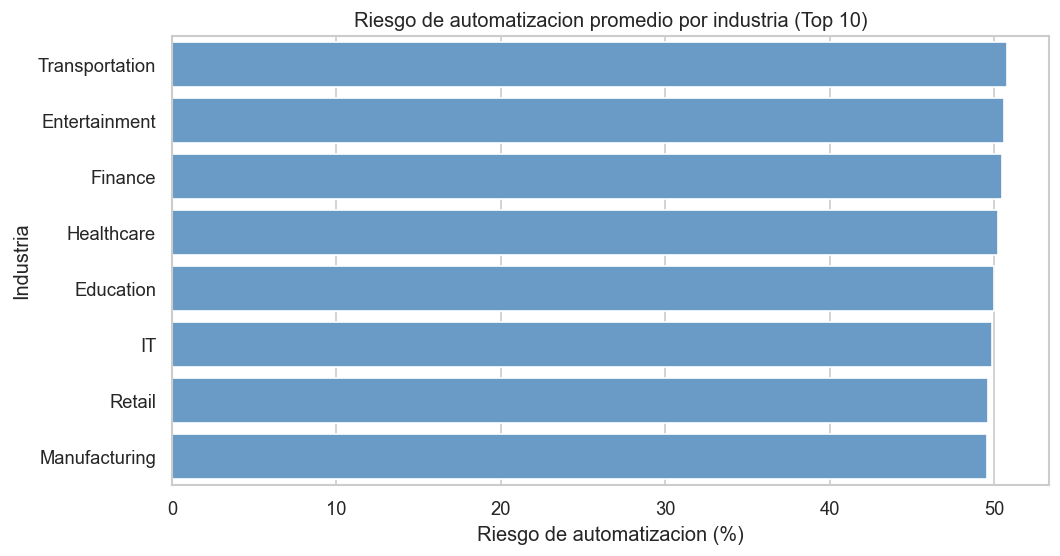

In [13]:
top_industry = (
    df.groupby("Industry")["automation_risk_pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .dropna()
 )

plt.figure(figsize=(9, 4.8))
sns.barplot(x=top_industry.values, y=top_industry.index, color="#5b9bd5")
plt.title("Riesgo de automatizacion promedio por industria (Top 10)")
plt.xlabel("Riesgo de automatizacion (%)")
plt.ylabel("Industria")
plt.tight_layout()
plt.show()

Interpretacion: las industrias con mayor riesgo promedio concentran tareas mas estandarizables. Esto ayuda a priorizar sectores donde la automatizacion puede tener mayor impacto.

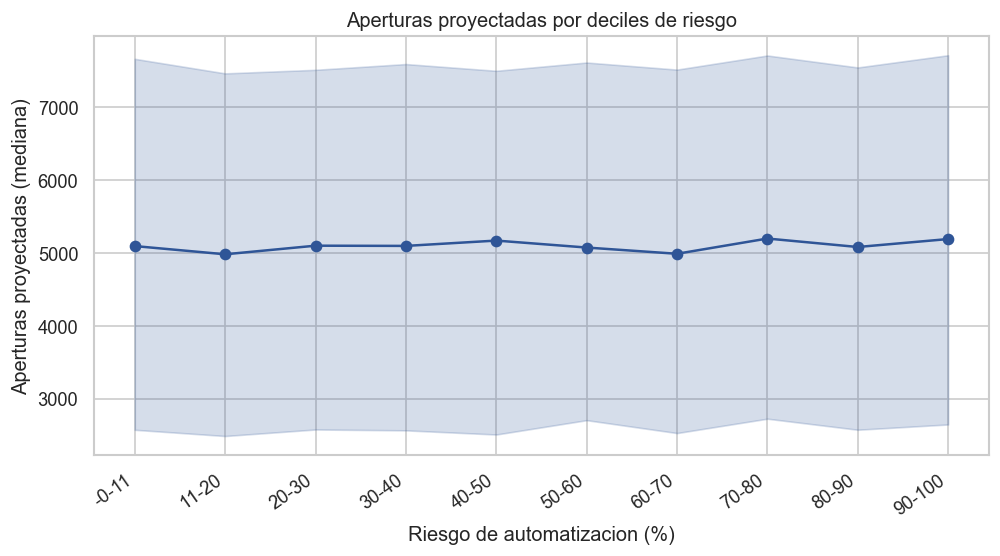

In [12]:
# Aperturas proyectadas por deciles de riesgo
risk_bins = pd.qcut(df["automation_risk_pct"], 10, duplicates="drop")
summary = (
    df.groupby(risk_bins)["projected_openings_2030"]
    .agg(median="median", q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75))
    .reset_index()
 )
summary["bin_label"] = summary["automation_risk_pct"].apply(
    lambda x: f"{x.left:.0f}-{x.right:.0f}"
 )

plt.figure(figsize=(8.5, 4.8))
plt.plot(summary.index, summary["median"], marker="o", color="#2f5597")
plt.fill_between(summary.index, summary["q1"], summary["q3"], alpha=0.2, color="#2f5597")
plt.xticks(summary.index, summary["bin_label"], rotation=35, ha="right")
plt.title("Aperturas proyectadas por deciles de riesgo")
plt.xlabel("Riesgo de automatizacion (%)")
plt.ylabel("Aperturas proyectadas (mediana)")
plt.tight_layout()
plt.show()

Interpretacion: la mediana de aperturas proyectadas cambia entre deciles de riesgo. La banda intercuartil muestra la dispersion y evita que casos extremos distorsionen la lectura.

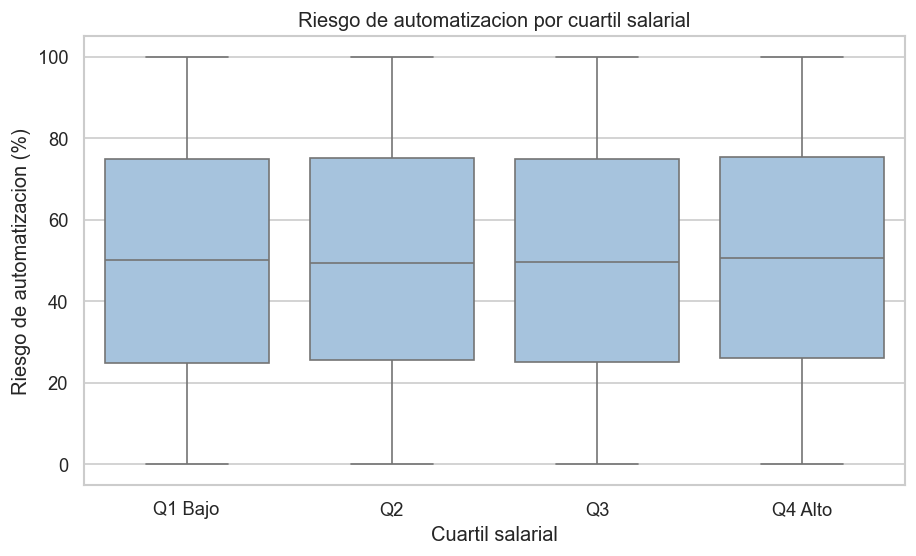

In [9]:
# Riesgo por cuartiles de salario
df["salary_quartile"] = pd.qcut(
    df["median_salary_usd"],
    4,
    labels=["Q1 Bajo", "Q2", "Q3", "Q4 Alto"],
 )

plt.figure(figsize=(7.8, 4.8))
sns.boxplot(
    data=df,
    x="salary_quartile",
    y="automation_risk_pct",
    color="#9dc3e6",
 )
plt.title("Riesgo de automatizacion por cuartil salarial")
plt.xlabel("Cuartil salarial")
plt.ylabel("Riesgo de automatizacion (%)")
plt.tight_layout()
plt.show()

Interpretacion: los cuartiles altos no eliminan el riesgo. La distribucion muestra que hay ocupaciones bien pagadas con exposicion relevante a automatizacion.

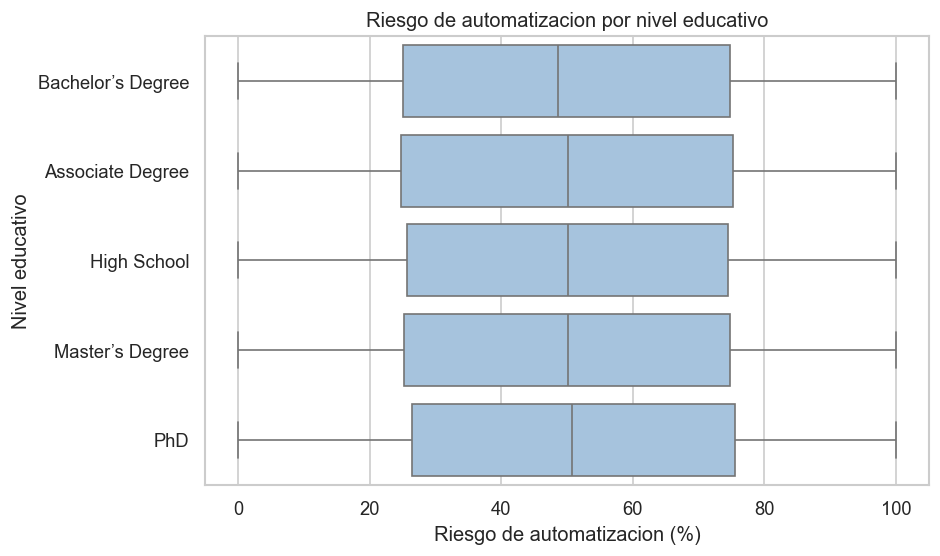

In [10]:
edu_order = (
    df.groupby("Required Education")["automation_risk_pct"]
    .median()
    .sort_values()
    .index
 )

plt.figure(figsize=(8, 4.8))
sns.boxplot(
    data=df,
    x="automation_risk_pct",
    y="Required Education",
    order=edu_order,
    color="#9dc3e6",
 )
plt.title("Riesgo de automatizacion por nivel educativo")
plt.xlabel("Riesgo de automatizacion (%)")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()

Interpretacion: niveles educativos distintos muestran dispersion en el riesgo. Esto sugiere que la formacion modera la exposicion, pero no la elimina.

In [11]:
norm_cols = ["automation_risk_pct", "projected_openings_2030", "median_salary_usd"]
for col in norm_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    df[f"{col}_norm"] = (df[col] - col_min) / (col_max - col_min)

df["impact_index"] = 0.5 * df["automation_risk_pct_norm"] + 0.5 * df["projected_openings_2030_norm"]

top_impact = (
    df[["Job Title", "Industry", "automation_risk_pct", "projected_openings_2030", "impact_index"]]
    .sort_values("impact_index", ascending=False)
    .head(10)
 )

top_impact

,Job Title,Industry,automation_risk_pct,projected_openings_2030,impact_index
14665,Fast food restaurant manager,Transportation,99.99,9972,0.998586
23289,"Teacher, secondary school",Manufacturing,99.89,9950,0.996975
17206,IT trainer,Healthcare,99.63,9944,0.995372
23750,Housing manager/officer,Education,99.12,9966,0.993932
16270,Chartered accountant,Manufacturing,98.71,9989,0.993044
12732,"Geologist, engineering",Education,99.78,9871,0.992435
24487,Arts development officer,IT,99.11,9914,0.991256
28329,Interior and spatial designer,Finance,99.84,9836,0.990967
22646,"Copywriter, advertising",Finance,98.17,9999,0.990849
4760,Toxicologist,Entertainment,99.57,9847,0.990173


Interpretacion: el indice combina riesgo y demanda futura en una sola escala. Sirve para priorizar ocupaciones con alto riesgo y alta demanda proyectada.